# Lab 01 — Chuyển ảnh màu sang Grayscale

Bài thực hành cho **issue #10**: dùng hàm source để chuyển ảnh màu sang mức xám, so sánh dữ liệu trước/sau và lưu kết quả PNG.

## 1. Mục tiêu

- Hiểu ảnh BGR ba kênh và grayscale một kênh.
- Quan sát shape, dtype và min/max trước/sau.
- Kiểm tra ảnh PNG đọc lại khớp từng pixel.

**Nguồn ảnh:** `lab_1/data/input/02_portrait_astronaut.jpg` trong repository. Thống kê và kết quả được tính từ ảnh này khi chạy notebook.

## 2. Chuẩn bị

Tại repository root trên Windows, chuẩn bị môi trường và mở Jupyter:

```powershell
python -m venv .venv
.venv/Scripts/python.exe -m pip install -r requirements.txt
.venv/Scripts/python.exe -m jupyter notebook
```

Chọn kernel của môi trường đã cài dependencies và mở `lab_1/notebook/03_grayscale.ipynb`. Nếu `.venv` đã có thì dùng lại môi trường đó. Notebook hỗ trợ kernel khởi động tại repository root hoặc `lab_1/notebook`. Chọn **Restart Kernel → Run All** để tái lập kết quả.

OpenCV đọc ảnh màu theo thứ tự **BGR**; Matplotlib hiển thị ảnh màu theo thứ tự **RGB**. Thư viện xử lý: OpenCV, NumPy, Matplotlib.

In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11, "figure.dpi": 110})
working_directory = Path.cwd().resolve()
project_root = next(
    (candidate for candidate in (working_directory, *working_directory.parents)
     if (candidate / "lab_1" / "src").is_dir()
     and (candidate / "lab_1" / "data" / "input" / "02_portrait_astronaut.jpg").is_file()
     and (candidate / "requirements.txt").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Không tìm thấy project. Khởi động kernel tại repository root hoặc "
        "lab_1/notebook và kiểm tra ảnh input."
    )
source_directory = project_root / "lab_1" / "src"
if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))
from color_space import bgr_to_grayscale

input_path = project_root / "lab_1" / "data" / "input" / "02_portrait_astronaut.jpg"
output_path = project_root / "lab_1" / "data" / "output" / "02_portrait_astronaut_gray.png"
print("Input:", input_path.relative_to(project_root))

Input: lab_1\data\input\02_portrait_astronaut.jpg


## 3. Đọc ảnh màu

Dùng `cv2.IMREAD_COLOR` để đọc BGR ba kênh. OpenCV trả `None` khi không đọc được file, nên kiểm tra trước khi chuyển đổi.

In [2]:
image_bgr = cv2.imread(str(input_path), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {input_path.relative_to(project_root)}")
if image_bgr.ndim != 3 or image_bgr.shape[2] != 3:
    raise ValueError("Ảnh minh họa phải có shape (H, W, 3).")
if image_bgr.dtype != np.uint8:
    raise TypeError("Ảnh minh họa phải có dtype uint8.")
print("Ảnh màu đã đọc:", image_bgr.shape, "| dtype:", image_bgr.dtype)

Ảnh màu đã đọc: (512, 512, 3) | dtype: uint8


## 4. Chuyển đổi và so sánh dữ liệu

Gọi `bgr_to_grayscale` từ `lab_1/src/color_space.py` để tái sử dụng thuật toán. Công thức gần đúng: **Y ≈ 0.299R + 0.587G + 0.114B**. Các kênh có trọng số khác nhau; grayscale không phải trung bình cộng ba kênh. Khi xuất `uint8`, OpenCV làm tròn giá trị.

In [3]:
image_gray = bgr_to_grayscale(image_bgr)

print(f"{'Ảnh':<14} {'Shape':<20} {'Dtype':<10} {'Min':>5} {'Max':>5}")
for label, image in [("BGR", image_bgr), ("Grayscale", image_gray)]:
    print(f"{label:<14} {str(image.shape):<20} {str(image.dtype):<10} "
          f"{int(image.min()):>5} {int(image.max()):>5}")
print("Min/max BGR được tính trên toàn bộ ba kênh.")

Ảnh            Shape                Dtype        Min   Max
BGR            (512, 512, 3)        uint8          0   255
Grayscale      (512, 512)           uint8          0   255
Min/max BGR được tính trên toàn bộ ba kênh.


### Ý nghĩa dữ liệu

- Shape `(H, W, 3)` trở thành `(H, W)`: chiều cao và chiều rộng giữ nguyên. Grayscale là ảnh **một kênh cường độ** dù mảng hai chiều không có trục kênh riêng.
- Thông tin màu bị mất; không thể khôi phục duy nhất ảnh màu ban đầu từ grayscale.
- `uint8` có **256 mức**: **0 là đen**, **255 là trắng**, ở giữa là các mức xám.
- **Min/max thực tế không bắt buộc bằng 0/255**; chúng phụ thuộc nội dung ảnh. Đọc giá trị quan sát được trong bảng phía trên.

## 5. Hiển thị trước và sau

Đổi ảnh gốc BGR → RGB trước khi hiển thị. Grayscale dùng thang cố định `0–255` để không tự kéo giãn độ tương phản theo min/max riêng của ảnh.

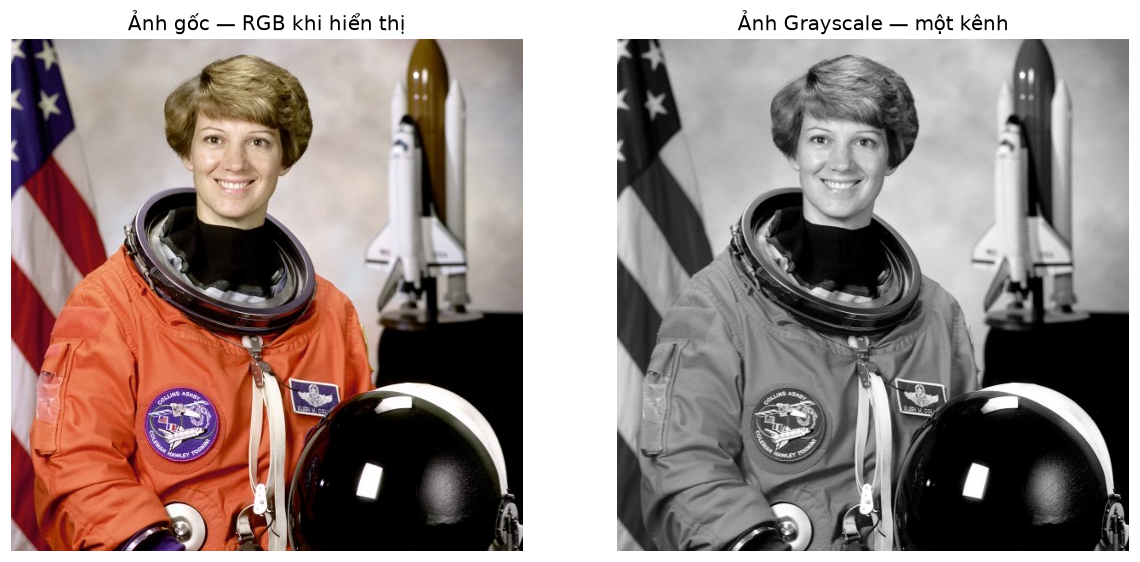

In [4]:
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
axes[0].imshow(image_rgb)
axes[0].set_title("Ảnh gốc — RGB khi hiển thị")
axes[1].imshow(image_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Ảnh Grayscale — một kênh")
for axis in axes:
    axis.axis("off")
plt.show()

## 6. Lưu PNG và kiểm tra

PNG lưu dữ liệu ảnh không mất mát. Kiểm tra giá trị trả về của `cv2.imwrite`, sau đó đọc lại bằng chế độ grayscale và đối chiếu từng pixel.

In [5]:
output_path.parent.mkdir(parents=True, exist_ok=True)
if not cv2.imwrite(str(output_path), image_gray):
    raise OSError(f"Không lưu được ảnh: {output_path.relative_to(project_root)}")
saved_gray = cv2.imread(str(output_path), cv2.IMREAD_GRAYSCALE)
if saved_gray is None:
    raise OSError("Ảnh PNG đã lưu không đọc lại được.")

assert image_gray.shape == image_bgr.shape[:2], "Kích thước ảnh đã thay đổi."
assert image_gray.dtype == np.uint8, "Dtype đầu ra phải là uint8."
assert 0 <= int(image_gray.min()) <= int(image_gray.max()) <= 255
assert saved_gray.dtype == image_gray.dtype
assert np.array_equal(saved_gray, image_gray), "PNG đọc lại không khớp dữ liệu đã lưu."
print("Đã lưu:", output_path.relative_to(project_root))
print("Kiểm tra đạt: kích thước, dtype, miền giá trị và PNG khớp từng pixel.")

Đã lưu: lab_1\data\output\02_portrait_astronaut_gray.png
Kiểm tra đạt: kích thước, dtype, miền giá trị và PNG khớp từng pixel.


## 7. Nhận xét và bàn giao

Hai ảnh ở phần 5 cho phép đối chiếu hình dạng và chi tiết ở cùng kích thước. Grayscale biểu diễn các vùng màu bằng cường độ sáng; các màu khác nhau có thể cho cùng mức xám.

Sau khi **Restart Kernel → Run All** thành công, notebook cung cấp bảng thống kê, ảnh so sánh và file `lab_1/data/output/02_portrait_astronaut_gray.png`. Các assertion kiểm tra kết quả của ảnh minh họa. Nếu đổi input, chạy lại toàn bộ notebook để cập nhật dữ liệu và output.